## Implementation of Query Enhancement - Decomposition into sub-queries

### Libraries, ChatOllama, Chroma vectorstore, LLM prompt initialization

In [1]:
from chromadb.config import Settings
from chromadb import Client
from langchain.vectorstores import Chroma
import chromadb

from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_core.documents import Document
from langchain_core.prompts import PromptTemplate
from typing_extensions import List, TypedDict
from langgraph.graph import START, StateGraph

import os, re, time
from datetime import datetime

date = datetime.today().strftime('%Y-%m-%d')
proj_name = "Query Enhancement (Decomposition)"
run_count = 1

# Initialize Langsmith
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_API_KEY"] = "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"
os.environ["LANGSMITH_PROJECT"] = f"[{date}] VAA - {proj_name} {run_count}"

# Initialize LLM
REASONING = True

llm = ChatOllama(model="deepseek-r1:8b", validate_model_on_init=True, temperature=0.6, reasoning=True if REASONING else False)
emb = OllamaEmbeddings(model="bge-m3:567m")

In [2]:
SINGLE = True # Change to True if you want to use single chroma database for all documents
collection_name = "polyu_eee_document" if not SINGLE else "vaa_documents"

# Initialize retriever for queries. Get the workspace root directory
import pathlib
workspace_root = pathlib.Path(__file__).parent.parent.parent if '__file__' in globals() else pathlib.Path.cwd().parent.parent.parent
chroma_db_path = workspace_root / "chroma_db"

print(chroma_db_path)

client = Client(Settings())
client = chromadb.PersistentClient(path=str(chroma_db_path))

vectorStore = Chroma(
    collection_name=collection_name, 
    client=client, 
    embedding_function=emb
)

client.get_collection(name=collection_name).count()

/Users/MarcussPC/Desktop/Temp/CAPSTONE/chroma_db


/var/folders/cf/1j9rc9v11rzf5wxcjw3w_wsm0000gp/T/ipykernel_23587/2427784666.py:14: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  vectorStore = Chroma(


4302

In [3]:
# The LLM prompt
LLM_prompt = \
    """
    You are a professional academic advisor at The Hong Kong Polytechnic University. Please adhere to the following rules:
        1. Answer in the same language as the user query, e.g., English query, English answer.
        2. Avoid saying "may", "maybe", or anything similar; be affirmative, confident, and decisive in your answers.
        3. Avoid saying "based on the provided context", or anything similar; answer directly.
        4. Say no if you cannot answer the question; do not fabricate a factually false answer.
        5. Provide advice to the student if necessary.

    Now, please use the following context to answer the student's question.
    Remember to be nice and ask if there are any more enquiries.

    *Context*:
    ----------
    {context}
    ----------

    *Student's Question*:
    {question}

    Helpful Answer:
    """
prompt = PromptTemplate.from_template(LLM_prompt)

### Decomposition and Answer recursively

In [4]:
num_queries = 3 # Number of additional queries to divide

# decompose prompt
DECOMPOSE_PROMPT = \
    """
    You are a helpful assistant that breaks down a complex user question into a series of simpler sub-queries.
    The sub-queries should be answerable in a step-by-step manner, building on top of each other.
    Provide {num_queries} sub-queries as a numbered list only. Do not say anything else.

    *User Question*: 
    {question}

    {num_queries} Sub-queries:
    """
decompose_question_prompt = PromptTemplate.from_template(DECOMPOSE_PROMPT)

In [5]:
# Defining the class structure for the LLM
class State(TypedDict):
    question: str
    sub_queries: List[str]
    context: List[Document]
    answer: str
    intermediate_answers: List[str]

# Functions for query decomposition
def decompose_question(state: State):
    question = state["question"]
    messages = decompose_question_prompt.invoke({"question": question, "num_queries": num_queries})
    response = llm.invoke(messages)
    sub_queries = []
    for line in response.content.split("\n"):
        sub_queries.append(line)
    return {"sub_queries": sub_queries, "intermediate_answers": []}

# Functions for document retrieval based on cos-sim
def retrieve(state: State):
    current_question = state["sub_queries"][len(state["intermediate_answers"])]
    context_for_question = "\n".join(state["intermediate_answers"])

    query = context_for_question + "\n" + current_question
    
    retrieved_docs = vectorStore.similarity_search(query, k=3)
    return {"context": retrieved_docs}

# Functions for constructing the final LLM prompt
def generate(state: State):
    current_question = state["sub_queries"][len(state["intermediate_answers"])]
    context_for_question = "\n".join(state["intermediate_answers"])
    
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"question": current_question, "context": context_for_question + "\n\n" + docs_content})
    response = llm.invoke(messages)
    
    new_intermediate_answers = state["intermediate_answers"] + [response.content]
    
    # Include the reasoning part in the output
    final_answer = response.content

    # NOT Include the reasoning part
    #final_answer = f"<think>\n{response.additional_kwargs.get('reasoning_content', '')}</think>\n\n{response.content}"

    return {"intermediate_answers": new_intermediate_answers, "answer": final_answer}

# NEW: Conditional edge function to check if more sub-queries need to be processed
def should_continue(state: State):
    if len(state["intermediate_answers"]) < len(state["sub_queries"]):
        return "continue"
    else:
        return "end"

# Functions for graph building (a process sequence)
def graph_building():
    global graph
    graph_builder = StateGraph(State)
    
    graph_builder.add_node("decompose", decompose_question)
    graph_builder.add_node("retrieve", retrieve)
    graph_builder.add_node("generate", generate)
    
    graph_builder.add_edge(START, "decompose")
    graph_builder.add_edge("decompose", "retrieve")
    graph_builder.add_edge("retrieve", "generate")
    
    graph_builder.add_conditional_edges(
        "generate",
        should_continue,
        {
            "continue": "retrieve",
            "end": "__end__"
        }
    )
    
    graph = graph_builder.compile()

graph_building()

### Optional: Testing

In [6]:
query = \
"What is the potential career path for studying in BEng Scheme in IAIE?"

print(f"Generating {query}")
result = graph.invoke({"question": query})

print(f"\nSub-questions generated:\n")
for q in result['sub_queries']:
    print(f"- {q}") 
print(f"\nPlease see Langsmith for the full details of the execution trace.\n")

Generating What is the potential career path for studying in BEng Scheme in IAIE?

Sub-questions generated:

- 1.  What specific areas of engineering does the BEng Scheme at IAIE cover, and are there particular specializations or concentrations within the program?
- 2.  What key technical and soft skills are typically developed during a BEng degree program at IAIE?
- 3.  Which industries or sectors commonly hire graduates with a BEng degree from IAIE, and what types of job roles or positions are available to them?

Please see Langsmith for the full details of the execution trace.



# =================================
### Define Test Dataset

In [7]:
# Test dataset with questions and expected answer
test_dataset = [
    {
        "question": "What is the potential career path after studying in BEng Scheme in EE?",
        "category": "career",
        "expected_keywords": ["engineer", "industry", "career", "professional"],
        "ground_truth": None
    },
    {
        "question": "How can I apply for residential hall in the PolyU?",
        "category": "university",
        "expected_keywords": ["admission", "application", "submit", "procedure"],
        "ground_truth": None
    },
    {
        "question": "What courses are offered in the first year in Master of Science in EIE?",
        "category": "curriculum",
        "expected_keywords": ["course", "year", "subject", "semester"],
        "ground_truth": None
    },
    {
        "question": "I am a year 3 student studying in BSc Information Security. What should I do if I failed a subject?",
        "category": "academic",
        "expected_keywords": ["retake", "GPA", "grade", "tie-subject"],
        "ground_truth": None
    },
    {
        "question": "Are there any internship opportunities available?",
        "category": "internship",
        "expected_keywords": ["internship", "placement", "work", "experience"],
        "ground_truth": None
    },
]

### Define Evaluation Metrics

In [8]:
import os, re, json
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from rouge_score import rouge_scorer
from bert_score import score as bert_score

class RetrievalMetrics:
    """Metrics to evaluate retrieval quality"""
    
    @staticmethod
    def safe_cosine_similarity(vec1, vec2):
        """Calculate cosine similarity with safety checks for numerical stability"""

        try:
            vec1 = np.array(vec1, dtype=np.float64)
            vec2 = np.array(vec2, dtype=np.float64)
            if np.any(np.isnan(vec1)) or np.any(np.isnan(vec2)):
                return 0.0
            if np.any(np.isinf(vec1)) or np.any(np.isinf(vec2)):
                return 0.0
            
            # Calculate norms
            norm1 = np.linalg.norm(vec1)
            norm2 = np.linalg.norm(vec2)
            
            # Check for zero-length vectors
            if norm1 == 0 or norm2 == 0:
                return 0.0
            
            # Calculate cosine similarity manually to avoid overflow
            dot_product = np.dot(vec1, vec2)
            similarity = dot_product / (norm1 * norm2)
            
            # Clip to valid range [-1, 1] to handle numerical errors
            similarity = np.clip(similarity, -1.0, 1.0)
            
            return float(similarity)
        except Exception as e:
            print(f"Error calculating cos similarity: {e}")
            return 0.0
    
    @staticmethod
    def calculate_retrieval_scores(query: str, retrieved_docs: List[Document], emb_model) -> dict:
        """Calculate various retrieval metrics with numerical stability"""

        if not retrieved_docs:
            return {
                "avg_similarity": 0, 
                "max_similarity": 0, 
                "min_similarity": 0, 
                "std_similarity": 0,
                "num_docs": 0
            }
        
        try:
            # Get query embedding & document embeddings
            query_embedding = emb_model.embed_query(query)
            doc_embeddings = [emb_model.embed_query(doc.page_content) for doc in retrieved_docs]
            
            # Calculate cosine similarities using safe method
            similarities = []
            for doc_emb in doc_embeddings:
                sim = RetrievalMetrics.safe_cosine_similarity(query_embedding, doc_emb)
                similarities.append(sim)
            
            # Filter out invalid similarities
            valid_similarities = [s for s in similarities if not np.isnan(s) and not np.isinf(s)]
            
            if not valid_similarities:
                return {
                    "avg_similarity": 0, 
                    "max_similarity": 0, 
                    "min_similarity": 0,
                    "std_similarity": 0, 
                    "num_docs": len(retrieved_docs)
                }
            
            return {
                "avg_similarity": float(np.mean(valid_similarities)),
                "max_similarity": float(np.max(valid_similarities)),
                "min_similarity": float(np.min(valid_similarities)),
                "std_similarity": float(np.std(valid_similarities)),
                "num_docs": len(retrieved_docs)
            }
        except Exception as e:
            print(f"Warning: Error in calculate_retrieval_scores: {e}")
            return {
                "avg_similarity": 0, 
                "max_similarity": 0, 
                "min_similarity": 0,
                "std_similarity": 0,
                "num_docs": len(retrieved_docs)
            }
    
    @staticmethod
    def calculate_diversity(retrieved_docs: List[Document]) -> float:
        """Calculate diversity of retrieved documents with numerical stability"""

        if len(retrieved_docs) < 2:
            return 0.0
        
        try:
            # Calculate pairwise similarity between documents
            doc_texts = [doc.page_content for doc in retrieved_docs]
            doc_embeddings = [emb.embed_query(text) for text in doc_texts]
            
            similarities = []
            for i in range(len(doc_embeddings)):
                for j in range(i + 1, len(doc_embeddings)):
                    sim = RetrievalMetrics.safe_cosine_similarity(doc_embeddings[i], doc_embeddings[j])
                    if not np.isnan(sim) and not np.isinf(sim):
                        similarities.append(sim)
            
            # Diversity is 1 - average similarity
            if not similarities:
                return 0.0
                
            return float(1 - np.mean(similarities))
        except Exception as e:
            print(f"Warning: Error calculating diversity: {e}")
            return 0.0

print("Retrieval metrics implemented")

class AnswerQualityMetrics:
    """Metrics to evaluate answer quality"""
    
    def __init__(self, llm_model):
        self.llm = llm_model
        self.rouge_scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    
    def calculate_faithfulness(self, answer: str, context_docs: List[Document]) -> float:
        """Calculate if answer is faithful to retrieved context using LLM"""

        context = "\n\n".join([doc.page_content for doc in context_docs])
        faithfulness_prompt = \
        f"""
        Evaluate if the following answer is faithful to the provided context.
        Answer only with a score from 0 to 10, where:
        - 0 means completely unfaithful (contradicts or invents information)
        - 10 means completely faithful (all information comes from context)
        
        Context:
        {context}
        
        Answer:
        {answer}
        
        Score (0-10):
        """
        
        try:
            response = self.llm.invoke(faithfulness_prompt)
            score_text = response.content.strip()
            score = float(re.search(r'\d+', score_text).group())
            return min(max(score / 10, 0), 1)  # Normalize to 0-1
        except:
            return 0.5  # Default if parsing fails
    
    def calculate_relevance(self, question: str, answer: str) -> float:
        """Calculate if answer is relevant to the question using LLM"""

        relevance_prompt = \
        f"""
        Evaluate if the following answer is relevant to the question.
        Answer only with a score from 0 to 10, where:
        - 0 means completely irrelevant
        - 10 means perfectly relevant and addresses the question
        
        Question:
        {question}
        
        Answer:
        {answer}
        
        Score (0-10):
        """
        
        try:
            response = self.llm.invoke(relevance_prompt)
            score_text = response.content.strip()
            score = float(re.search(r'\d+', score_text).group())
            return min(max(score / 10, 0), 1)
        except:
            return 0.5
    
    def calculate_completeness(self, question: str, answer: str) -> float:
        """Calculate if answer completely addresses the question"""

        completeness_prompt = \
        f"""
        Evaluate if the following answer completely addresses all aspects of the question.
        Answer only with a score from 0 to 10, where:
        - 0 means very incomplete or missing key information
        - 10 means fully complete and comprehensive
        
        Question:
        {question}
        
        Answer:
        {answer}
        
        Score (0-10):
        """
        
        try:
            response = self.llm.invoke(completeness_prompt)
            score_text = response.content.strip()
            score = float(re.search(r'\d+', score_text).group())
            return min(max(score / 10, 0), 1)
        except:
            return 0.5
    
    def check_keyword_coverage(self, answer: str, expected_keywords: List[str]) -> float:
        """Check how many expected keywords appear in the answer"""

        if not expected_keywords:
            return 1.0
        
        answer_lower = answer.lower()
        found = sum(1 for keyword in expected_keywords if keyword.lower() in answer_lower)
        return found / len(expected_keywords)
    
    def calculate_rouge_scores(self, answer: str, reference: str) -> dict:
        """Calculate ROUGE scores if reference answer is available"""

        if not reference:
            return {"rouge1": None, "rouge2": None, "rougeL": None}
        
        scores = self.rouge_scorer.score(reference, answer)
        return {
            "rouge1": scores['rouge1'].fmeasure,
            "rouge2": scores['rouge2'].fmeasure,
            "rougeL": scores['rougeL'].fmeasure
        }

answer_metrics = AnswerQualityMetrics(llm)
print("Answer quality metrics implemented")

class AdditionalMetrics:
    """Additional evaluation metrics"""
    
    @staticmethod
    def calculate_answer_length(answer: str) -> dict:
        """Calculate answer length statistics"""

        words = answer.split()
        return {
            "word_count": len(words),
            "char_count": len(answer),
            "sentence_count": len(re.split(r'[.!?]+', answer))
        }
    
    @staticmethod
    def detect_hallucination_indicators(answer: str) -> dict:
        """Detect potential hallucination indicators"""

        uncertainty_words = ['may', 'maybe', 'possibly', 'perhaps', 'might', 'could']
        hedging_phrases = ['based on', 'according to', 'it seems', 'it appears']
        answer_lower = answer.lower()
        
        return {
            "has_uncertainty": any(word in answer_lower for word in uncertainty_words),
            "has_hedging": any(phrase in answer_lower for phrase in hedging_phrases),
            "uncertainty_count": sum(1 for word in uncertainty_words if word in answer_lower)
        }
    
    @staticmethod
    def calculate_context_utilization(answer: str, context_docs: List[Document]) -> float:
        """Estimate how much of the context was used in the answer"""
        if not context_docs:
            return 0.0
        
        context_text = " ".join([doc.page_content for doc in context_docs])
        context_words = set(context_text.lower().split())
        answer_words = set(answer.lower().split())
        
        # Remove common stop words
        stop_words = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'is', 'are', 'was', 'were', 'be'}
        context_words -= stop_words
        answer_words -= stop_words
        
        if not context_words:
            return 0.0
        
        overlap = len(answer_words.intersection(context_words))
        return overlap / len(context_words) if context_words else 0.0

additional_metrics = AdditionalMetrics()
print("Additional metrics implemented")

Retrieval metrics implemented
Answer quality metrics implemented
Additional metrics implemented


### Evaluation Process

In [9]:
def evaluate_single_query(test_item: dict, graph, emb_model, answer_metrics) -> dict:
    """Evaluate a single query comprehensively. This function extracts all metrics including retrieval quality, answer quality, and hallucination status."""

    question = test_item["question"]
    
    print(f"\nEvaluating: {question}")
    
    # Run RAG system
    result = graph.invoke({"question": question})
    answer = result["answer"]
    retrieved_docs = result.get("context")  # MAKE SURE: State the correct dict key: ('context' or 'retrieved_docs')
    
    # Calculate all metrics
    evaluation = {
        "question": question,
        "category": test_item["category"],
        "answer": answer,
    }

    print(f"Retrieved {len(retrieved_docs)} documents")
    
    # Retrieval metrics
    retrieval_scores = RetrievalMetrics.calculate_retrieval_scores(question, retrieved_docs, emb_model)
    evaluation.update({f"retrieval_{k}": v for k, v in retrieval_scores.items()})
    evaluation["retrieval_diversity"] = RetrievalMetrics.calculate_diversity(retrieved_docs)
    
    # Answer quality metrics
    evaluation["faithfulness"] = answer_metrics.calculate_faithfulness(answer, retrieved_docs)
    evaluation["relevance"] = answer_metrics.calculate_relevance(question, answer)
    evaluation["completeness"] = answer_metrics.calculate_completeness(question, answer)
    evaluation["keyword_coverage"] = answer_metrics.check_keyword_coverage(answer, test_item["expected_keywords"])
    
    # Additional metrics
    length_stats = additional_metrics.calculate_answer_length(answer)
    evaluation.update({f"length_{k}": v for k, v in length_stats.items()})
    
    hallucination_indicators = additional_metrics.detect_hallucination_indicators(answer)
    evaluation.update({f"hallucination_{k}": v for k, v in hallucination_indicators.items()})
    
    evaluation["context_utilization"] = additional_metrics.calculate_context_utilization(answer, retrieved_docs)
    
    # ROUGE scores (only if ground truth is available)
    if test_item.get("ground_truth"):
        rouge_scores = answer_metrics.calculate_rouge_scores(answer, test_item["ground_truth"])
        evaluation.update({f"rouge_{k}": v for k, v in rouge_scores.items()})
    
    print(f"Faithfulness: {evaluation['faithfulness']:.3f}")
    print(f"Relevance: {evaluation['relevance']:.3f}")
    print(f"Completeness: {evaluation['completeness']:.3f}")
    print(f"Retrieval Avg Similarity: {evaluation.get('retrieval_avg_similarity', 0):.3f}")
    print(f"Context Utilization: {evaluation.get('context_utilization', 0):.3f}")
    
    return evaluation

print("Evaluation ready")

Evaluation ready


In [10]:
# Run evaluation on all test data
print("STARTING COMPREHENSIVE RAG EVALUATION")

results = []
for test_item in test_dataset:
    eval_result = evaluate_single_query(test_item, graph, emb, answer_metrics)
    results.append(eval_result)

print(f"\n{len(results)} queries evaluated")

STARTING COMPREHENSIVE RAG EVALUATION

Evaluating: What is the potential career path after studying in BEng Scheme in EE?
Retrieved 3 documents
Faithfulness: 0.000
Relevance: 1.000
Completeness: 0.900
Retrieval Avg Similarity: 0.625
Context Utilization: 0.135

Evaluating: How can I apply for residential hall in the PolyU?
Retrieved 3 documents
Faithfulness: 0.200
Relevance: 0.200
Completeness: 0.200
Retrieval Avg Similarity: 0.530
Context Utilization: 0.047

Evaluating: What courses are offered in the first year in Master of Science in EIE?
Retrieved 3 documents
Faithfulness: 0.000
Relevance: 0.900
Completeness: 0.900
Retrieval Avg Similarity: 0.576
Context Utilization: 0.056

Evaluating: I am a year 3 student studying in BSc Information Security. What should I do if I failed a subject?
Retrieved 3 documents
Faithfulness: 0.000
Relevance: 0.900
Completeness: 0.700
Retrieval Avg Similarity: 0.621
Context Utilization: 0.137

Evaluating: Are there any internship opportunities available?
R

### Results Analysis and Visualization

In [11]:
# Convert results to DataFrame
df_results = pd.DataFrame(results)

# Display summary statistics
print("EVALUATION SUMMARY STATISTICS\n")

metric_columns = [
    'faithfulness', 'relevance', 'completeness', 'keyword_coverage',
    'retrieval_avg_similarity', 'retrieval_diversity', 'context_utilization'
]

summary_stats = df_results[metric_columns].describe()
print(summary_stats.round(3))

# Save results
df_results.to_csv('Evaluation/rag_evaluation_results.csv', index=False)
print("\nResults saved")

EVALUATION SUMMARY STATISTICS

       faithfulness  relevance  completeness  keyword_coverage  \
count         5.000      5.000         5.000             5.000   
mean          0.180      0.760         0.720             0.600   
std           0.303      0.321         0.303             0.379   
min           0.000      0.200         0.200             0.000   
25%           0.000      0.800         0.700             0.500   
50%           0.000      0.900         0.900             0.750   
75%           0.200      0.900         0.900             0.750   
max           0.700      1.000         0.900             1.000   

       retrieval_avg_similarity  retrieval_diversity  context_utilization  
count                     5.000                5.000                5.000  
mean                      0.581                0.206                0.097  
std                       0.041                0.094                0.043  
min                       0.530                0.106                0.

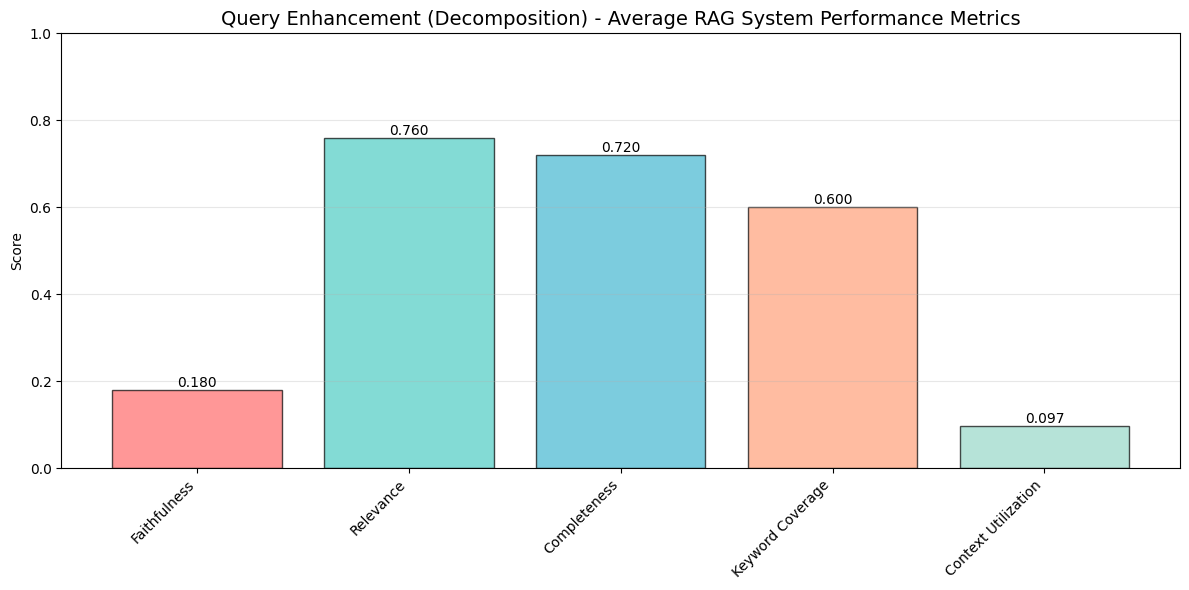

Metrics comparison chart saved


In [12]:
# Visualization 1: Overall Metrics Comparison
plt.figure(figsize=(12, 6))

metrics_to_plot = ['faithfulness', 'relevance', 'completeness', 'keyword_coverage', 'context_utilization']
avg_scores = df_results[metrics_to_plot].mean()

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
bars = plt.bar(range(len(avg_scores)), avg_scores.values, color=colors, alpha=0.7, edgecolor='black')
plt.xticks(range(len(avg_scores)), [m.replace('_', ' ').title() for m in metrics_to_plot], rotation=45, ha='right')
plt.ylabel('Score')
plt.title(f'{proj_name} - Average RAG System Performance Metrics', fontsize=14)
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('Evaluation/rag_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Metrics comparison chart saved")

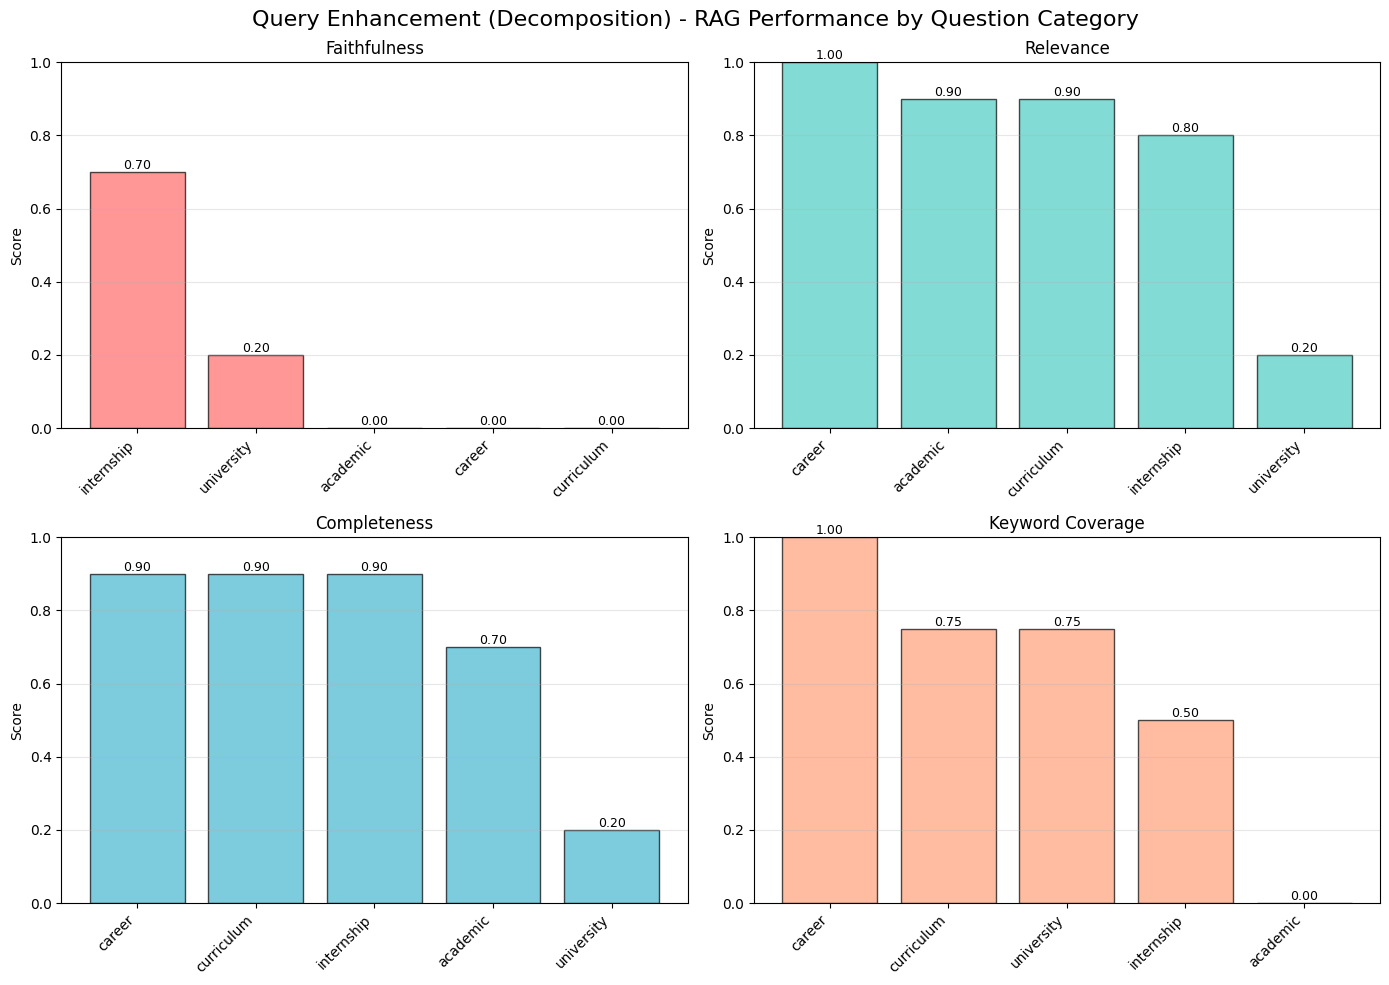

Category performance chart saved


In [13]:
# Visualization 2: Performance by Category
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{proj_name} - RAG Performance by Question Category', fontsize=16)

metrics = ['faithfulness', 'relevance', 'completeness', 'keyword_coverage']
titles = ['Faithfulness', 'Relevance', 'Completeness', 'Keyword Coverage']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]
    category_scores = df_results.groupby('category')[metric].mean().sort_values(ascending=False)
    
    bars = ax.bar(range(len(category_scores)), category_scores.values, color=colors[idx], alpha=0.7, edgecolor='black')
    ax.set_xticks(range(len(category_scores)))
    ax.set_xticklabels(category_scores.index, rotation=45, ha='right')
    ax.set_ylabel('Score')
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('Evaluation/rag_category_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Category performance chart saved")

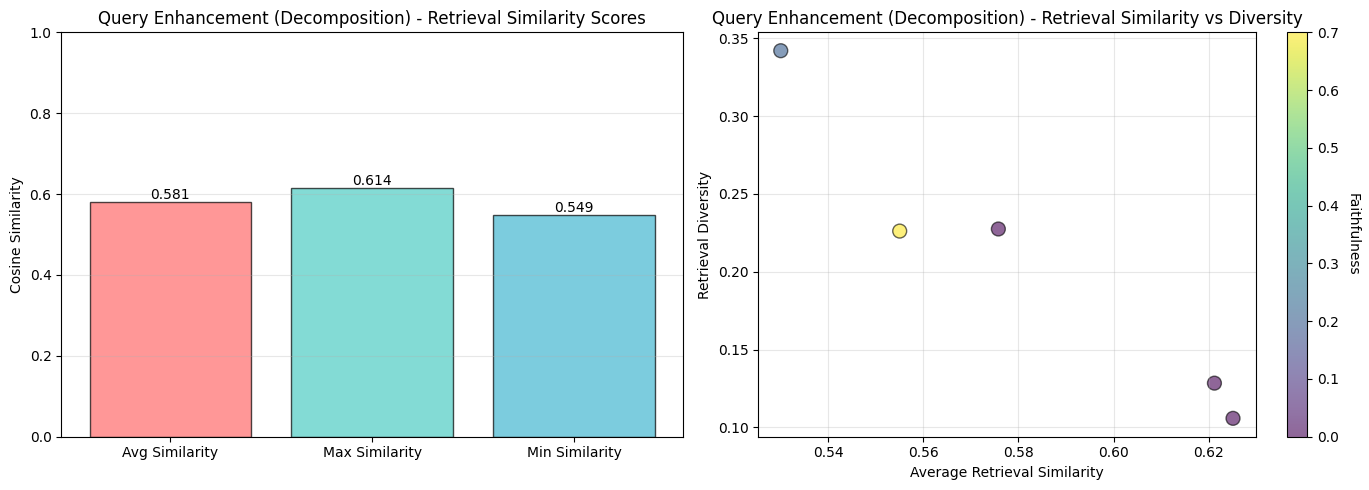

Retrieval analysis chart saved


In [14]:
# Visualization 3: Retrieval Quality Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Retrieval similarity distribution
ax1 = axes[0]
retrieval_metrics = ['retrieval_avg_similarity', 'retrieval_max_similarity', 'retrieval_min_similarity']
retrieval_data = df_results[retrieval_metrics].mean()

bars1 = ax1.bar(range(len(retrieval_data)), retrieval_data.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.7, edgecolor='black')
ax1.set_xticks(range(len(retrieval_data)))
ax1.set_xticklabels(['Avg Similarity', 'Max Similarity', 'Min Similarity'])
ax1.set_ylabel('Cosine Similarity')
ax1.set_title(f'{proj_name} - Retrieval Similarity Scores')
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}', ha='center', va='bottom')

# Diversity vs Similarity scatter
ax2 = axes[1]
scatter = ax2.scatter(df_results['retrieval_avg_similarity'], df_results['retrieval_diversity'], c=df_results['faithfulness'], cmap='viridis', s=100, alpha=0.6, edgecolor='black')
ax2.set_xlabel('Average Retrieval Similarity')
ax2.set_ylabel('Retrieval Diversity')
ax2.set_title(f'{proj_name} - Retrieval Similarity vs Diversity')
ax2.grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Faithfulness', rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig('Evaluation/rag_retrieval_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Retrieval analysis chart saved")

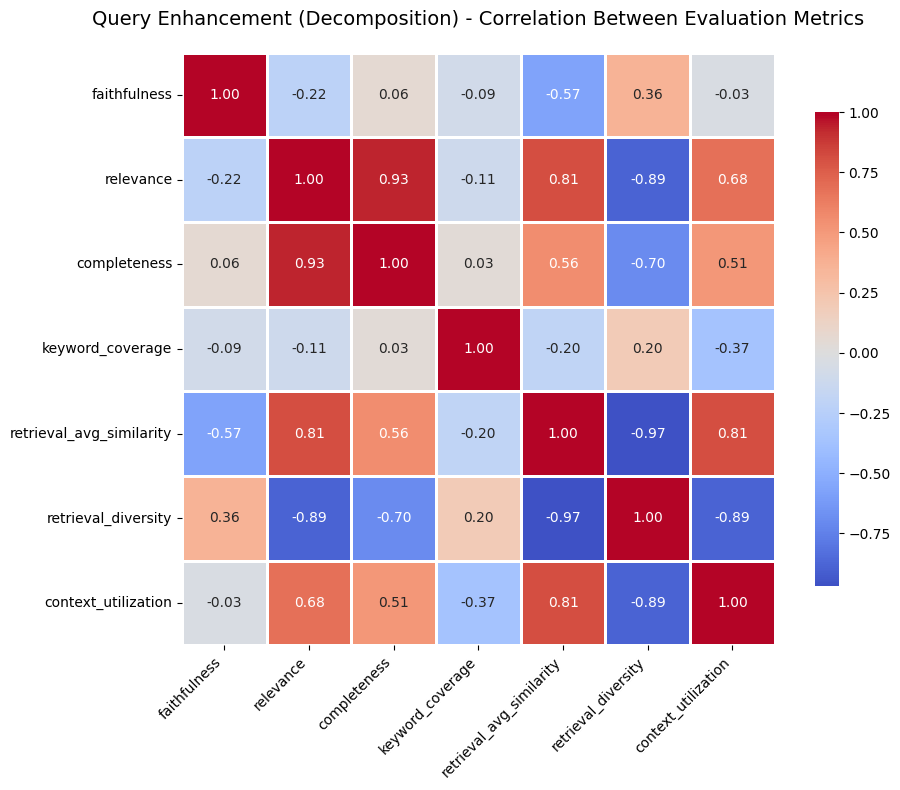

Correlation heatmap saved


In [15]:
# Visualization 4: Answer Quality Heatmap
plt.figure(figsize=(10, 8))

# Create correlation matrix
quality_metrics = ['faithfulness', 'relevance', 'completeness', 'keyword_coverage', 'retrieval_avg_similarity', 'retrieval_diversity', 'context_utilization']
correlation_matrix = df_results[quality_metrics].corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title(f'{proj_name} - Correlation Between Evaluation Metrics', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('Evaluation/rag_metrics_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("Correlation heatmap saved")

### DETAILED Report

In [16]:
# Generate detailed report
print(f"{proj_name} - DETAILED EVALUATION REPORT\n")

# Overall performance
print("\nOVERALL PERFORMANCE (mean:standard-deviation):")
for metric in metric_columns:
    mean_val = df_results[metric].mean()
    std_val = df_results[metric].std()
    print(f"{metric} --- {mean_val:.3f} ± {std_val:.3f}")

# Best and worst performing queries
print("\nBEST PERFORMING QUERY:")
best_idx = df_results['faithfulness'].idxmax()
print(f"Question: {df_results.loc[best_idx, 'question']}")
print(f"Faithfulness: {df_results.loc[best_idx, 'faithfulness']:.3f}")
print(f"Relevance: {df_results.loc[best_idx, 'relevance']:.3f}")
print(f"Completeness: {df_results.loc[best_idx, 'completeness']:.3f}")

print("\nWEAKEST PERFORMING QUERY:")
worst_idx = df_results['faithfulness'].idxmin()
print(f"Question: {df_results.loc[worst_idx, 'question']}")
print(f"Faithfulness: {df_results.loc[worst_idx, 'faithfulness']:.3f}")
print(f"Relevance: {df_results.loc[worst_idx, 'relevance']:.3f}")
print(f"Completeness: {df_results.loc[worst_idx, 'completeness']:.3f}")

# Category analysis
print("\nPERFORMANCE BY CATEGORY:")
for category in df_results['category'].unique():
    cat_data = df_results[df_results['category'] == category]
    print(f"\n{category.upper()}:")
    print(f"  Faithfulness: {cat_data['faithfulness'].mean():.3f}")
    print(f"  Relevance: {cat_data['relevance'].mean():.3f}")
    print(f"  Completeness: {cat_data['completeness'].mean():.3f}")
    print(f"  Keyword Coverage: {cat_data['keyword_coverage'].mean():.3f}")

# Hallucination analysis
print("\nHALLUCINATION?")
print(f"Queries with uncertainty words: {df_results['hallucination_has_uncertainty'].sum()}/{len(df_results)}")
print(f"Queries with hedging phrases: {df_results['hallucination_has_hedging'].sum()}/{len(df_results)}")
print(f"Average uncertainty count: {df_results['hallucination_uncertainty_count'].mean():.2f}")

print("\n\nEVALUATION COMPLETE")

Query Enhancement (Decomposition) - DETAILED EVALUATION REPORT


OVERALL PERFORMANCE (mean:standard-deviation):
faithfulness --- 0.180 ± 0.303
relevance --- 0.760 ± 0.321
completeness --- 0.720 ± 0.303
keyword_coverage --- 0.600 ± 0.379
retrieval_avg_similarity --- 0.581 ± 0.041
retrieval_diversity --- 0.206 ± 0.094
context_utilization --- 0.097 ± 0.043

BEST PERFORMING QUERY:
Question: Are there any internship opportunities available?
Faithfulness: 0.700
Relevance: 0.800
Completeness: 0.900

WEAKEST PERFORMING QUERY:
Question: What is the potential career path after studying in BEng Scheme in EE?
Faithfulness: 0.000
Relevance: 1.000
Completeness: 0.900

PERFORMANCE BY CATEGORY:

CAREER:
  Faithfulness: 0.000
  Relevance: 1.000
  Completeness: 0.900
  Keyword Coverage: 1.000

UNIVERSITY:
  Faithfulness: 0.200
  Relevance: 0.200
  Completeness: 0.200
  Keyword Coverage: 0.750

CURRICULUM:
  Faithfulness: 0.000
  Relevance: 0.900
  Completeness: 0.900
  Keyword Coverage: 0.750

ACADEMIC:

### Addition

In [17]:
# Create comprehensive JSON report
report = {
    "evaluation_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "dataset_info": {
        "total_queries": len(test_dataset),
        "evaluated_queries": len(results),
        "categories": list(df_results['category'].unique())
    },
    "overall_metrics": {
        metric: {
            "mean": float(df_results[metric].mean()),
            "std": float(df_results[metric].std()),
            "min": float(df_results[metric].min()),
            "max": float(df_results[metric].max())
        }
        for metric in metric_columns
    },
    "category_performance": {
        category: {
            metric: float(df_results[df_results['category'] == category][metric].mean())
            for metric in ['faithfulness', 'relevance', 'completeness', 'keyword_coverage']
        }
        for category in df_results['category'].unique()
    },
    "detailed_results": results
}

with open('Evaluation/rag_evaluation_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print("Full evaluation report saved")

Full evaluation report saved
